In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

--- Task (a): CO2 Emission Prediction ---
CO2 Model R-squared (R²): 0.8071


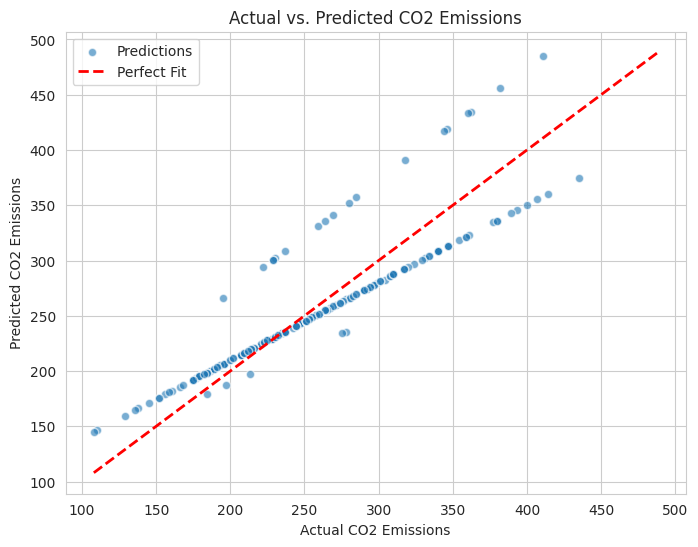

In [2]:
print("--- Task (a): CO2 Emission Prediction ---")

try:
    fuel_df = pd.read_csv('fuel_consumption_dataset.csv')
except FileNotFoundError:
    print("Error: 'fuel_consumption_dataset.csv' not found.")
    print("Please make sure you have uploaded the file to your Colab environment.")
except Exception as e:
    print(f"An error occurred: {e}")

if 'fuel_df' in locals():
    X = fuel_df[['FUELCONSUMPTION_COMB']]
    y = fuel_df['CO2EMISSIONS']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model_fuel = LinearRegression()
    model_fuel.fit(X_train, y_train)

    y_pred_fuel = model_fuel.predict(X_test)

    r2_fuel = r2_score(y_test, y_pred_fuel)
    print(f"CO2 Model R-squared (R²): {r2_fuel:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_fuel, alpha=0.6, edgecolors='w', label='Predictions')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual CO2 Emissions")
    plt.ylabel("Predicted CO2 Emissions")
    plt.title("Actual vs. Predicted CO2 Emissions")
    plt.legend()
    plt.show()


--- Task (b): Used Car Price Prediction ---
Used Car Price Model R-squared (R²): 0.2194


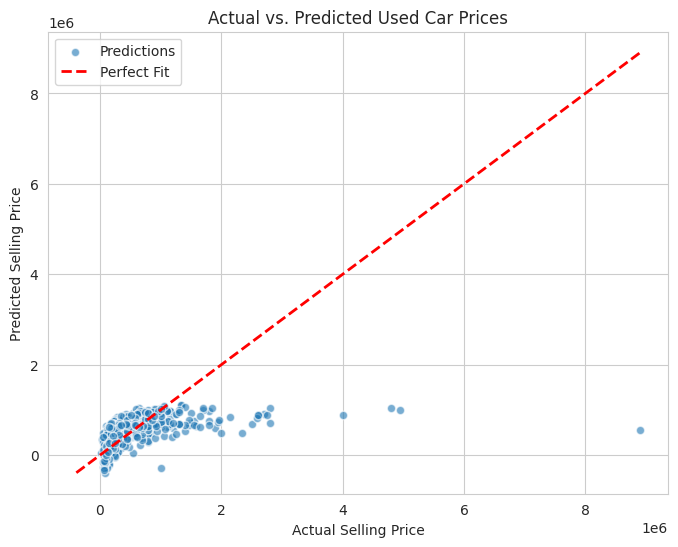

In [6]:
print("\n--- Task (b): Used Car Price Prediction ---")

try:
    cars_df = pd.read_csv('used_cars_dataset.csv')
except FileNotFoundError:
    print("Error: 'used_cars_dataset.csv' not found.")
    print("Please make sure you have uploaded the file to your Colab environment.")
except Exception as e:
    print(f"An error occurred: {e}")

if 'cars_df' in locals():
    target_column = 'selling_price'

    cars_df = cars_df.dropna(subset=[target_column])

    features = ['year', 'km_driven', 'fuel']
    target = target_column

    X = cars_df[features]
    y = cars_df[target]

    numeric_features = ['year', 'km_driven']
    categorical_features = ['fuel']

    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    model_cars = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model_cars.fit(X_train, y_train)

    y_pred_cars = model_cars.predict(X_test)

    r2_cars = r2_score(y_test, y_pred_cars)
    print(f"Used Car Price Model R-squared (R²): {r2_cars:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_cars, alpha=0.6, edgecolors='w', label='Predictions')
    min_val = min(y_test.min(), y_pred_cars.min())
    max_val = max(y_test.max(), y_pred_cars.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual Selling Price")
    plt.ylabel("Predicted Selling Price")
    plt.title("Actual vs. Predicted Used Car Prices")
    plt.legend()
    plt.show()